<a href="https://colab.research.google.com/github/Daarwinmendez/Daarwinmendez/blob/main/intent_recognition_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El dataset fue obtenido de obtenido de: https://www.kaggle.com/datasets/fahadrehman07/movie-reviews-and-emotion-dataset

In [ ]:
# Instalar virtualenv si no está instalado
!pip install virtualenv --quiet

# Crear un entorno virtual en Colab
!virtualenv my_env

# Activar el entorno virtual
!source my_env/bin/activate

# Instalar librerías dentro del entorno virtual
!pip install numpy==1.26.4 scipy==1.11.2 nltk --quiet

# Comprobar instalación
!pip list


created virtual environment CPython3.10.12.final.0-64 in 530ms
  creator CPython3Posix(dest=/content/my_env, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, wheel=bundle, via=copy, app_data_dir=/root/.local/share/virtualenv)
    added seed packages: pip==24.3.1, setuptools==75.6.0, wheel==0.45.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator
Package                            Version
---------------------------------- --------------------
absl-py                            1.4.0
accelerate                         1.2.1
aiohappyeyeballs                   2.4.4
aiohttp                            3.11.10
aiosignal                          1.3.2
alabaster                          1.0.0
albucore                           0.0.19
albumentations                     1.4.20
altair                             5.5.0
annotated-types                    0.7.0
anyascii    

In [ ]:
!pip install numpy==1.26.4 scipy==1.11.2 nltk py3langid contractions  --quiet

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.probability import FreqDist
import py3langid as langid
import requests
import string
import contractions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [ ]:
# Descargar los recursos específicos
nltk.download("stopwords")  # Stopwords como 'the', 'is', etc.
nltk.download("punkt")  # Tokenización de palabras y oraciones
nltk.download("names")  # Conjunto de nombres categorizados
nltk.download("wordnet")  # Base de datos léxica WordNet
nltk.download("averaged_perceptron_tagger")  # Etiquetador POS
nltk.download("tagsets")  # Descripción de etiquetas POS

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


True

## Analisis de entrada (Primario)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

In [ ]:
# Ruta a tu carpeta en Google Drive
drive_path = '/content/drive/MyDrive'
folder_name = 'Sentiment-analysis'
folder_path = os.path.join(drive_path, folder_name)

# Verificar si la carpeta existe
if os.path.exists(folder_path):
  print(f"La carpeta '{folder_name}' existe en tu Google Drive.")
  with open(os.path.join(folder_path, "Movies_Reviews_modified_version1.csv"), "r") as f:
    print("Cargando archivo...")
    loaded_df = pd.read_csv(f,
                            index_col=0,
                            low_memory=False)
    print("El archivo se cargo correctamente.")
else:
  print(f"La carpeta '{folder_name}' no existe en tu Google Drive, creandola...")
  os.makedirs(folder_path)
  print(f"La carpeta '{folder_name}' se ha creado exitosamente en tu Google Drive.")

La carpeta 'Sentiment-analysis' existe en tu Google Drive.
Cargando archivo...
El archivo se cargo correctamente.


In [ ]:
df = loaded_df

In [ ]:
df = loaded_df

In [ ]:
df.describe()

,Ratings
count,46173.000000
mean,5.983735
std,2.893144
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,10.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46173 entries, 0 to 46172
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ratings      46173 non-null  float64
 1   Reviews      46173 non-null  object 
 2   movie_name   46173 non-null  object 
 3   Resenhas     46173 non-null  object 
 4   genres       46173 non-null  object 
 5   Description  46173 non-null  object 
 6   emotion      46173 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.8+ MB


In [ ]:
df.isna().sum()

,0
Ratings,0
Reviews,0
movie_name,0
Resenhas,0
genres,0
Description,0
emotion,0


In [ ]:
df.shape

(46173, 7)

In [ ]:
df.size

323211

In [ ]:
df.nunique() # Numero de datos unicos por cada colummna.

,0
Ratings,10
Reviews,19316
movie_name,1583
Resenhas,19316
genres,697
Description,2060
emotion,8


#### Podemos apreciar que hay 8 emociones distintas

<Axes: >

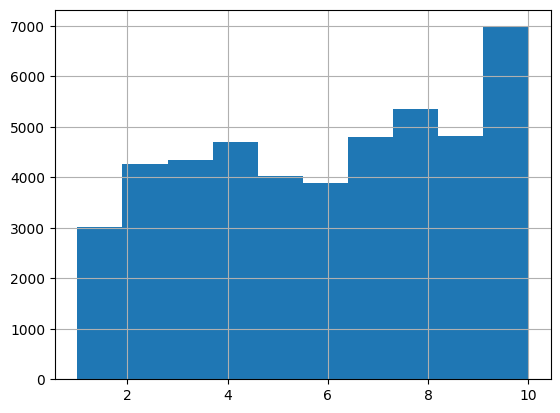

In [ ]:
df["Ratings"].hist()

<Axes: xlabel='Ratings'>

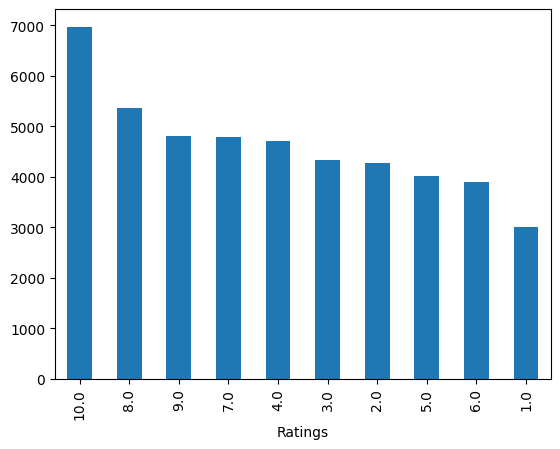

In [ ]:
df["Ratings"].value_counts().plot.bar()

<Axes: xlabel='emotion'>

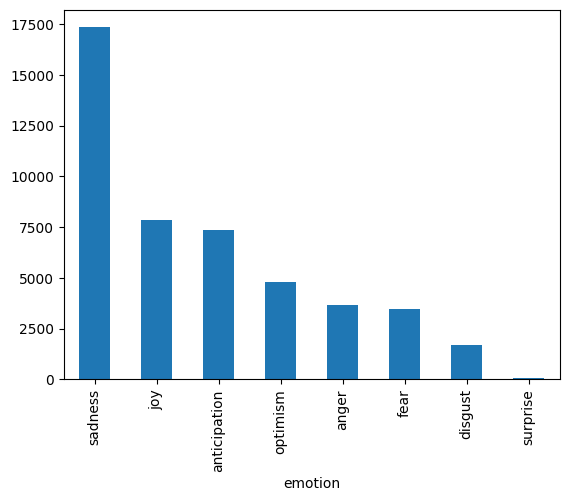

In [ ]:
df["emotion"].value_counts().plot.bar()

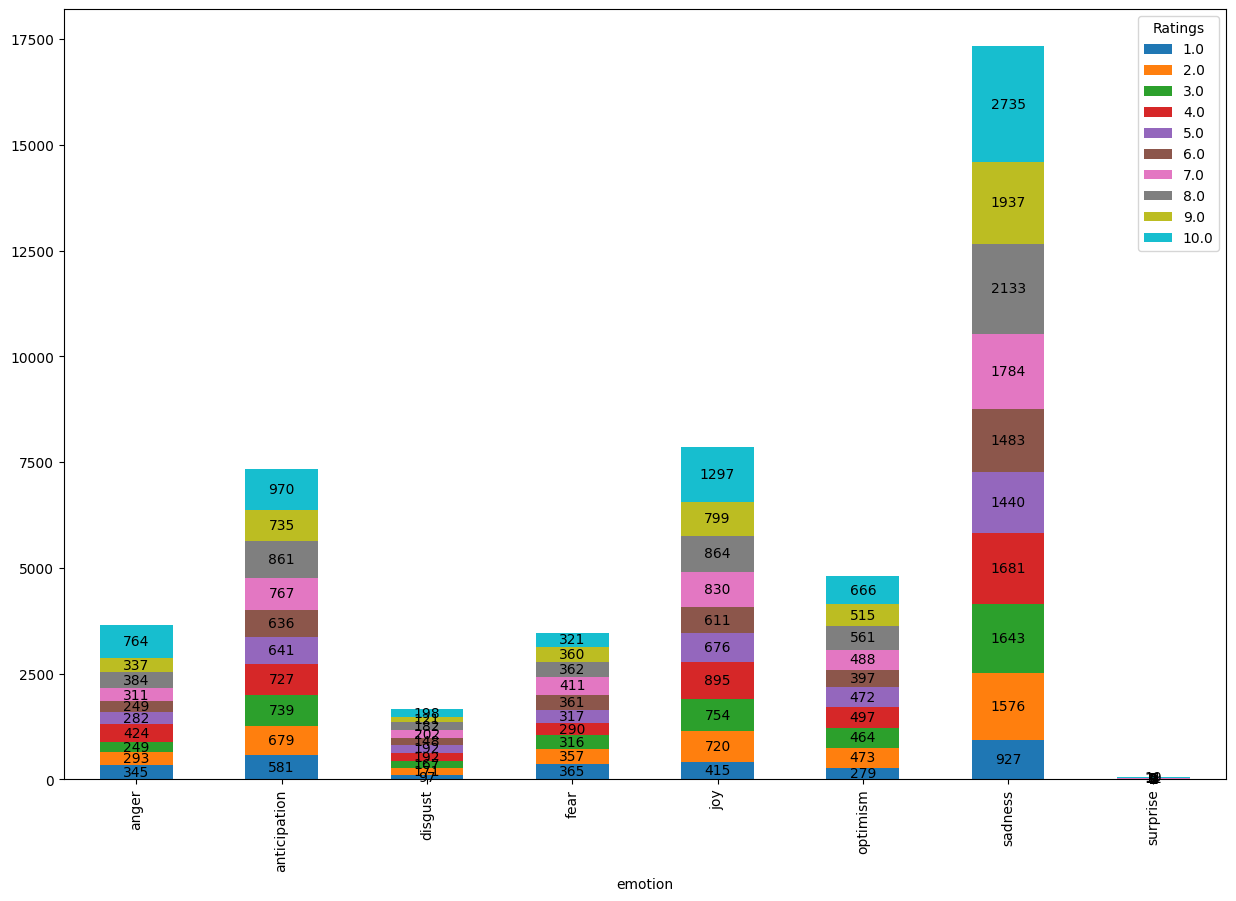

In [ ]:
rating_by_emotion = df.groupby("emotion")["Ratings"].value_counts().unstack()




ax =rating_by_emotion.plot(kind="bar", stacked=True, figsize=(15, 10))

for container in ax.containers:
    ax.bar_label(container, label_type="center")


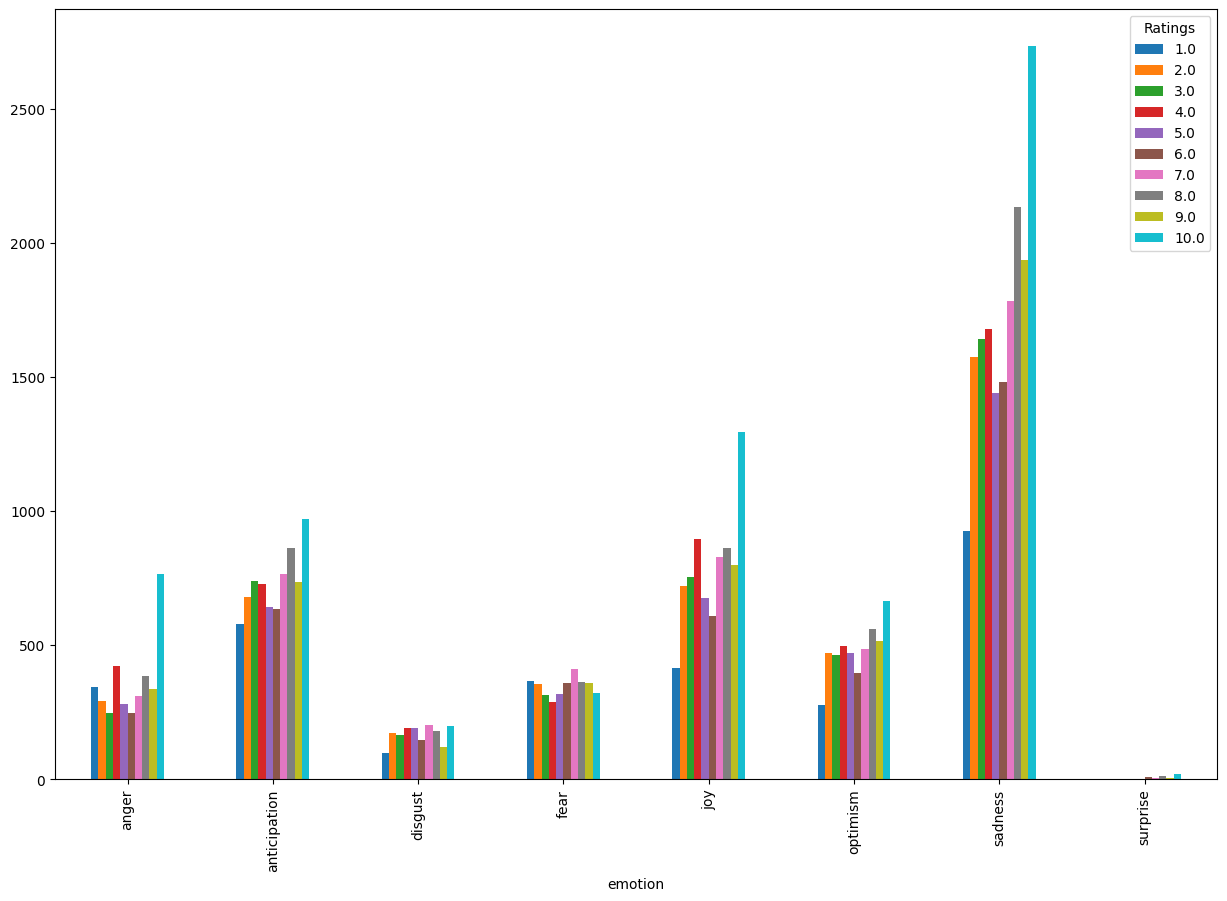

In [ ]:
rating_by_emotion = df.groupby("emotion")["Ratings"].value_counts().unstack()




ax =rating_by_emotion.plot(kind="bar", stacked=False, figsize=(15, 10))


In [ ]:
rating_by_emotion = df.groupby("emotion")["Ratings"].value_counts()

rating_by_emotion

emotion   Ratings
anger     10.0       764
          4.0        424
          8.0        384
          1.0        345
          9.0        337
                    ... 
surprise  7.0          5
          2.0          3
          3.0          3
          4.0          2
          5.0          1
Name: count, Length: 79, dtype: int64

### De las 8 emociones distintas que hay, observemoslas mas a detalle

In [ ]:
df["emotion"].value_counts()

,count
emotion,
sadness,17339
joy,7861
anticipation,7336
optimism,4812
anger,3638
fear,3460
disgust,1670
surprise,57


#### Podemos inferir que `surprise` es una categoría atípica, tendremos que eliminarla, y aplicar undersampling sobre las demas.

#### Por el bien de los demas, también eliminare `disgust`, ya que es también menos que el resto.

In [ ]:
df[df["emotion"].apply(lambda x: x != "surprise" and x != "disgust")]

,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
...,...,...,...,...,...,...,...
46168,10.0,10/10 buying this the second it's out online. ...,Robin Hood,10/10 comprando este no segundo que sai online...,"['Drama', 'Action', 'Romance']",Add a Plot,anticipation
46169,4.0,"""Lady Jayne:Killer"" is a bottom of the barrel ...",Betrayal,"""Lady Jayne: Killer"" é uma parte inferior do f...","['Action', 'Drama', 'Thriller']",Felix and Misela are father and daughter and o...,sadness
46170,4.0,"""Lady Jayne:Killer"" is a bottom of the barrel ...",Betrayal,"""Lady Jayne: Killer"" é uma parte inferior do f...","['Action', 'Drama', 'Thriller']",After being ditched by long term girlfriend Ge...,sadness
46171,5.0,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...","['Action', 'Drama', 'Thriller']",Felix and Misela are father and daughter and o...,sadness


In [ ]:
categorias = [cat for cat in df["emotion"].unique().tolist() if cat != "disgust" and cat != "surprise"]

for cat in categorias:
    print(f"La categoría {cat} tiene: { df[df['emotion'] == cat]['emotion'].count()  }")

La categoría anticipation tiene: 7336
La categoría sadness tiene: 17339
La categoría joy tiene: 7861
La categoría fear tiene: 3460
La categoría optimism tiene: 4812
La categoría anger tiene: 3638


In [ ]:
def get_data_for_NLP(df):
    df_for_nlp = {}

    df_for_nlp["reviews"] = df[df["emotion"].apply(lambda x: x != "surprise" and x != "disgust")]["Reviews"]

    df_for_nlp["emotion"] = df[df["emotion"].apply(lambda x: x != "surprise" and x != "disgust")]["emotion"]

    return df_for_nlp

In [ ]:
print(f"Cantidad de filas que ya NO se usarán: {len(df) - len(df[df['emotion'].apply(lambda x: x != 'surprise' and x != 'disgust')])}")

Cantidad de filas que ya NO se usarán: 1727


In [ ]:
df_for_NLP  = pd.DataFrame(get_data_for_NLP(df)).reset_index(drop=True) # Reseteando el indice, en caso de que un metaData se haya pasado.
df_for_NLP

,reviews,emotion
0,"It had some laughs, but overall the motivation...",anticipation
1,"WAITING TO EXHALE Waiting, and waiting, and wa...",anticipation
2,"Angela Basset was good as expected, but Whitne...",anticipation
3,"The movie is okay, mediocre might even be the ...",anticipation
4,I got an opportunity to see Waiting To Exhale ...,anticipation
...,...,...
44441,10/10 buying this the second it's out online. ...,anticipation
44442,"""Lady Jayne:Killer"" is a bottom of the barrel ...",sadness
44443,"""Lady Jayne:Killer"" is a bottom of the barrel ...",sadness
44444,"As thrillers go, there are a few surprises her...",sadness


In [ ]:
df_for_NLP.shape

(44446, 2)

In [ ]:
df_for_NLP.describe()

,reviews,emotion
count,44446,44446
unique,18763,6
top,Typically I have a soft spot in my heart for I...,sadness
freq,72,17339


### UnderSampling

In [ ]:
df_for_NLP.head()

,reviews,emotion
0,"It had some laughs, but overall the motivation...",anticipation
1,"WAITING TO EXHALE Waiting, and waiting, and wa...",anticipation
2,"Angela Basset was good as expected, but Whitne...",anticipation
3,"The movie is okay, mediocre might even be the ...",anticipation
4,I got an opportunity to see Waiting To Exhale ...,anticipation


In [ ]:
df_for_NLP.tail()

,reviews,emotion
44441,10/10 buying this the second it's out online. ...,anticipation
44442,"""Lady Jayne:Killer"" is a bottom of the barrel ...",sadness
44443,"""Lady Jayne:Killer"" is a bottom of the barrel ...",sadness
44444,"As thrillers go, there are a few surprises her...",sadness
44445,"As thrillers go, there are a few surprises her...",sadness


In [ ]:
no_dupl_df = df_for_NLP.drop_duplicates()

In [ ]:
no_dupl_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22733 entries, 0 to 44240
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   reviews  22733 non-null  object
 1   emotion  22733 non-null  object
dtypes: object(2)
memory usage: 532.8+ KB


In [ ]:
no_dupl_df.describe()

,reviews,emotion
count,22733,22733
unique,18763,6
top,This movie is awful. I just wasted precious mi...,sadness
freq,5,8696


In [ ]:
no_dupl_df["emotion"].value_counts(normalize=False)

,count
emotion,
sadness,8696
joy,4162
anticipation,3824
optimism,2682
fear,1884
anger,1485


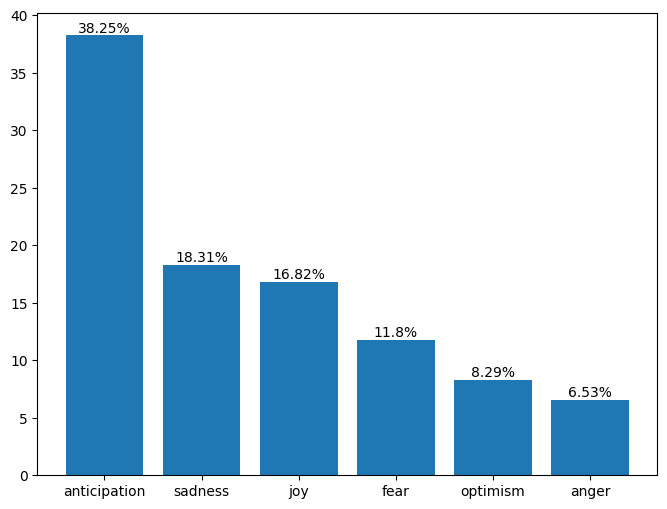

In [ ]:
fig, ax =  plt.subplots(figsize=(8, 6))




barras = ax.bar(x=no_dupl_df["emotion"].unique().tolist(), height= [ pct*100 for pct in no_dupl_df["emotion"].value_counts(normalize=True)])

for barra in barras:
    width = barra.get_x() + barra.get_width()/2
    height = barra.get_height()
    ax.text(x=width, y= height, s=f"{round(height,2)}%", va="bottom", ha="center")


In [ ]:
def under_sample(no_dupl_df):
    """ Toma un set de dato sin duplicados y busca en la columna target cual valor es menos frecuente,
        luego vuelve a todos de la misma cantidad/frecuencia, para que esten balanceados y retorna un diccionario
    """
    under_sampled_df = []

    keys =no_dupl_df["emotion"].value_counts().keys().to_list()

    values  = no_dupl_df["emotion"].value_counts().values.tolist()

    #print(np.min(values))

    threshold = np.min(values)
    index = values.index(threshold) # indice del elemento minimo


    for key in keys:
        emotion = no_dupl_df.loc[no_dupl_df["emotion"] == key]
        if len(emotion) > threshold:
            sampled = emotion.sample(threshold)
            under_sampled_df.append(sampled)

    under_sampled_df.append(no_dupl_df.loc[no_dupl_df["emotion"] == keys[index]])
    return pd.concat(under_sampled_df)

under_sampled_df = under_sample(no_dupl_df)
under_sampled_df


,reviews,emotion
17115,Face it. When a man stops getting what he want...,sadness
15621,If you're all set for a BAD-MOVIE night then y...,sadness
21541,"Enter Veronica 'Ronnie' Miller, a recently gra...",sadness
14625,"Wonderful film, fine directing, cinematography...",sadness
19059,Beverly Hills Chihuahua was a fun and very ent...,sadness
...,...,...
42897,people who made/make negative reviews knew exa...,anger
42898,If you read the books then you will love the f...,anger
43292,"Knowing nothing of BuckWild, I was left guessi...",anger
43293,"4 of 10. As slow as zombies are, this film is ...",anger


In [ ]:
under_sampled_df["emotion"].unique()

array(['sadness', 'joy', 'anticipation', 'optimism', 'fear', 'anger'],
      dtype=object)

In [ ]:
def under_sample(no_dupl_df):
    """ Toma un set de dato sin duplicados y busca en la columna target cual valor es menos frecuente,
        luego vuelve a todos de la misma cantidad/frecuencia, para que esten balanceados y retorna un diccionario
    """
    under_sampled_df = []

    keys =no_dupl_df["emotion"].value_counts().keys().to_list()

    values  = no_dupl_df["emotion"].value_counts().values.tolist()

    #print(np.min(values))

    #threshold = 300
    threshold = np.min(values)
    index = values.index(threshold) # indice del elemento minimo
    print(threshold)

    for key in keys:
        emotion = no_dupl_df.loc[no_dupl_df["emotion"] == key]
        if len(emotion) > threshold:
            sampled = emotion.sample(threshold)
            under_sampled_df.append(sampled)

    under_sampled_df.append(no_dupl_df.loc[no_dupl_df["emotion"] == keys[index]])
    return pd.concat(under_sampled_df)

under_sampled_df = under_sample(no_dupl_df)
under_sampled_df["emotion"].unique()


1485


array(['sadness', 'joy', 'anticipation', 'optimism', 'fear', 'anger'],
      dtype=object)

In [ ]:
# Fracción de todo el dataset
(no_dupl_df.loc[no_dupl_df["emotion"] == "anticipation"])

,reviews,emotion
0,"It had some laughs, but overall the motivation...",anticipation
1,"WAITING TO EXHALE Waiting, and waiting, and wa...",anticipation
2,"Angela Basset was good as expected, but Whitne...",anticipation
3,"The movie is okay, mediocre might even be the ...",anticipation
4,I got an opportunity to see Waiting To Exhale ...,anticipation
...,...,...
44236,This is a remarkable look at what passed for r...,anticipation
44237,"Well... what can I say, the title gives it awa...",anticipation
44238,"'Nude on the Moon' is the first, and perhaps f...",anticipation
44239,I've seen hundreds of B-grade movies and have ...,anticipation


In [ ]:
#print("Cantidad posible de filas para para procesar: {}".format(1485 * len(no_dupl_df["emotion"].unique().tolist())))

In [ ]:
sampled_df = under_sampled_df.sample(frac=1) # Sampleados denuevo, para cambiar orden

sampled_df = sampled_df.reset_index(drop=True)
sampled_df

,reviews,emotion
0,"I was apprehensive, to say the least, when I w...",anticipation
1,Love and Other Drugs is a film that combines c...,sadness
2,"In case you are not aware of it, this makes Ph...",sadness
3,For teens I highly recommend this movie. It is...,sadness
4,"I saw this movie,knowing that Tarkovski isn't ...",fear
...,...,...
8905,I liked this series until lately. It had it's ...,anger
8906,To summarize it - Clean entertainment.....good...,fear
8907,I was excited to see this film because the tea...,anger
8908,Damnit. I'm ashamed of Hollywood !! How did th...,joy


In [ ]:
sampled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8910 entries, 0 to 8909
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   reviews  8910 non-null   object
 1   emotion  8910 non-null   object
dtypes: object(2)
memory usage: 139.3+ KB


In [ ]:
sampled_df.describe()

,reviews,emotion
count,8910,8910
unique,8104,6
top,I really am astonished by Bollywood for castin...,anticipation
freq,5,1485


In [ ]:
sampled_df.isna().sum()

,0
reviews,0
emotion,0


In [ ]:
sampled_df["emotion"].value_counts(normalize=False)

,count
emotion,
anticipation,1485
sadness,1485
fear,1485
joy,1485
anger,1485
optimism,1485


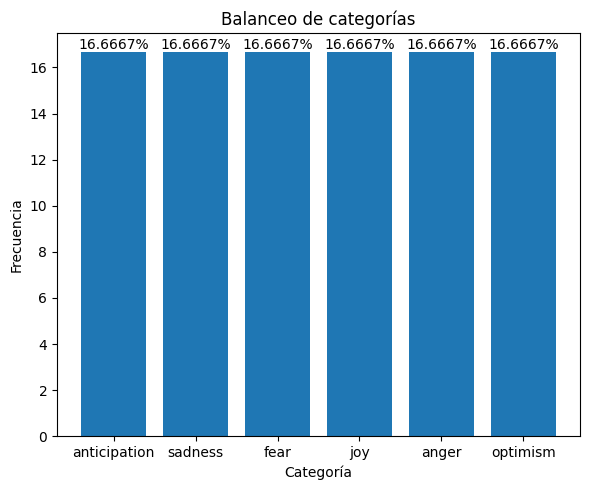

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))


barras = ax.bar(x=sampled_df["emotion"].unique().tolist(), height=[pct*100 for pct in sampled_df["emotion"].value_counts(normalize=True).tolist()])

for barra in barras:
    width =barra.get_x() + barra.get_width()/2
    height = barra.get_height()

    ax.text(x=width, y=height, s=f"{round(height, 4)}%", va="bottom", ha="center")

ax.set(
    title="Balanceo de categorías",
    xlabel="Categoría",
    ylabel="Frecuencia"
)

plt.tight_layout()
plt.show()

In [ ]:
print("El review de menos longitud es de: {}".format(np.min(sampled_df['reviews'].apply(lambda x: len(x)))))

El review de menos longitud es de: 49


<Axes: >

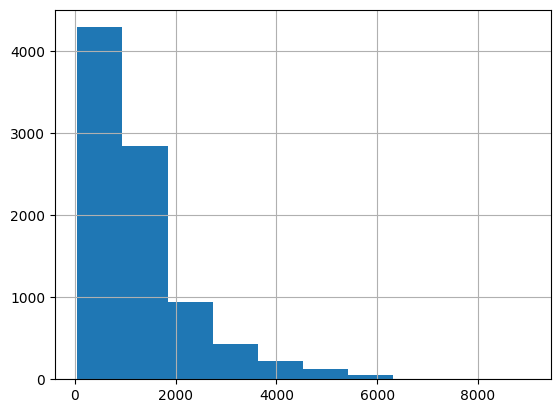

In [ ]:
sampled_df["reviews"].apply(lambda x: len(x)).hist()

### Viendo el Idioma

In [ ]:
# Trae todas las filas cuyo review sea en ingles, -- SEGÚN langid
sampled_df = sampled_df.loc[sampled_df["reviews"].apply(lambda x: langid.classify(x)[0] == 'en')].reset_index(drop=True)
sampled_df

,reviews,emotion
0,"I was apprehensive, to say the least, when I w...",anticipation
1,Love and Other Drugs is a film that combines c...,sadness
2,"In case you are not aware of it, this makes Ph...",sadness
3,For teens I highly recommend this movie. It is...,sadness
4,"I saw this movie,knowing that Tarkovski isn't ...",fear
...,...,...
8903,I liked this series until lately. It had it's ...,anger
8904,To summarize it - Clean entertainment.....good...,fear
8905,I was excited to see this film because the tea...,anger
8906,Damnit. I'm ashamed of Hollywood !! How did th...,joy


In [ ]:
import pandas as pd

def detect_language(text):
    if langid.classify(text)[0] == 'en':
        return 'en'
    else:
        return 'other'

# Aplicar la función de detección de idioma a la columna 'reviews'
sampled_df['detected_language'] = sampled_df['reviews'].apply(detect_language)

# Filtrar las filas cuyos 'reviews' estén en inglés (código de idioma 'en')
sampled_df_en = sampled_df[sampled_df['detected_language'] == 'en'].reset_index(drop=True)

# Mostrar el DataFrame filtrado
sampled_df_en


,reviews,emotion,detected_language
0,"I was apprehensive, to say the least, when I w...",anticipation,en
1,Love and Other Drugs is a film that combines c...,sadness,en
2,"In case you are not aware of it, this makes Ph...",sadness,en
3,For teens I highly recommend this movie. It is...,sadness,en
4,"I saw this movie,knowing that Tarkovski isn't ...",fear,en
...,...,...,...
8903,I liked this series until lately. It had it's ...,anger,en
8904,To summarize it - Clean entertainment.....good...,fear,en
8905,I was excited to see this film because the tea...,anger,en
8906,Damnit. I'm ashamed of Hollywood !! How did th...,joy,en


In [ ]:
sampled_df = sampled_df_en.reset_index(drop=True)
sampled_df

,reviews,emotion,detected_language
0,"I was apprehensive, to say the least, when I w...",anticipation,en
1,Love and Other Drugs is a film that combines c...,sadness,en
2,"In case you are not aware of it, this makes Ph...",sadness,en
3,For teens I highly recommend this movie. It is...,sadness,en
4,"I saw this movie,knowing that Tarkovski isn't ...",fear,en
...,...,...,...
8903,I liked this series until lately. It had it's ...,anger,en
8904,To summarize it - Clean entertainment.....good...,fear,en
8905,I was excited to see this film because the tea...,anger,en
8906,Damnit. I'm ashamed of Hollywood !! How did th...,joy,en


In [ ]:
sampled_df["detected_language"].value_counts()

,count
detected_language,
en,8908


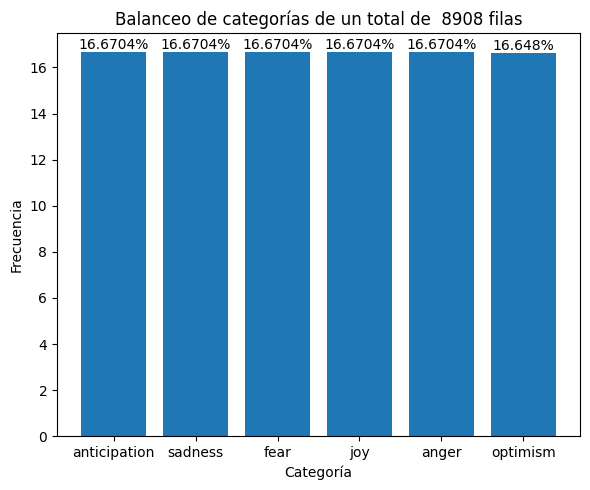

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))


barras = ax.bar(x=sampled_df["emotion"].unique().tolist(), height=[pct*100 for pct in sampled_df["emotion"].value_counts(normalize=True).tolist()])

for barra in barras:
    width =barra.get_x() + barra.get_width()/2
    height = barra.get_height()

    ax.text(x=width, y=height, s=f"{round(height, 4)}%", va="bottom", ha="center")

ax.set(
    title=f"Balanceo de categorías de un total de  {len(sampled_df['emotion'])} filas",
    xlabel="Categoría",
    ylabel="Frecuencia"
)

plt.tight_layout()
plt.show()

In [ ]:
# Probando fix, del modulo contractions
contractions.fix("Here we go again, I told you to stop, didn't I?")

'Here we go again, I told you to stop, did not I?'

In [ ]:
# Descargar el tagset de nltk
nltk.download('tagsets_json')

[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!


True

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [ ]:
pos_tag(["Hola mundo", "Hey"])

[('Hola mundo', 'NNP'), ('Hey', 'NNP')]

In [ ]:
pos_tag(["Hola mundo", "Hey"])[0][1][:2]

'NN'

In [ ]:
import re
def clean_text(text):
    # Eliminar tokens con más de 3 caracteres que son iguales
    cleaned_text = re.sub(r'(.)\1{2,}', '', text)  # elimina cadenas repetidas de 3 o más caracteres
    return cleaned_text

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [ ]:

def tokenize(oracion, metodo):
    """
    Toma una oración, expande contracciones, tokeniza y limpia los tokens.

    Args:
        oracion (str): La oración a procesar.
        metodo (str): El método de procesamiento a aplicar ("stemming" o "lemmatization").

    Returns:
        list: Una lista de tokens limpios procesados.
    """

    oracion = contractions.fix(oracion)

    tokens =  word_tokenize(oracion)
    stopwords = nltk.corpus.stopwords.words("english")
    names =  nltk.corpus.names.words()

    cleaned_tokens = []

    for token in tokens:
        if token in names: continue

        token = token.lower()

        if token in stopwords: continue
        if token in string.punctuation: continue
        if not token.isalnum(): continue
        cleaned_tokens.append(clean_text(token))



    #Filtrando por tag de palabras
    cleaned_tokens = [token for token, cat in pos_tag(cleaned_tokens) if cat[:2] in  ["NN", "VB", "RB", "JJ"]]
    if metodo == "stemming":
        #stemming
        cleaned_tokens = [stemmer.stem(token) for token in cleaned_tokens]

    elif metodo == "lemmatization":
        cleaned_tokens = [lemmatizer.lemmatize(token) for token in cleaned_tokens]
    else:
        cleaned_tokens = [lemmatizer.lemmatize(token) for token in cleaned_tokens]

    return cleaned_tokens

In [ ]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
tokenize("The 44 machine learning model analyzes large datasets and makes predictions based on patterns it finds.", "lemmatization") # tokenize("The 44 machine learning model analyzes large datasets and makes predictions

['machine',
 'learning',
 'model',
 'analyzes',
 'large',
 'datasets',
 'make',
 'prediction',
 'based',
 'pattern',
 'find']

In [ ]:
####  Probaremos sin numeros a ver que tal nos va.

In [ ]:
sampled_df["tokens"] = sampled_df["reviews"].apply(lambda x: tokenize(x, "lemmatization"))

In [ ]:
sampled_df["tokens"]

,tokens
0,"[apprehensive, say, least, went, see, tangled,..."
1,"[drug, film, combine, comedy, drama, romance, ..."
2,"[case, aware, make, officially, influential, s..."
3,"[teen, highly, recommend, movie, much, better,..."
4,"[saw, movie, knowing, tarkovski, amusing, thou..."
...,...
8903,"[liked, series, lately, ups, down, held, inter..."
8904,"[summarize, clean, entertainment, good, comedy..."
8905,"[excited, see, film, teaser, seemed, funny, en..."
8906,"[damnit, ashamed, hollywood, approved, stupid,..."


In [ ]:
sampled_df["emotion"].unique().tolist()

['anticipation', 'sadness', 'fear', 'joy', 'anger', 'optimism']

In [ ]:
sampled_df

,reviews,emotion,detected_language,tokens,training_tokens_lemma,training_tokens_stemm
0,"I was apprehensive, to say the least, when I w...",anticipation,en,"[apprehensive, say, least, went, see, tangled,...",apprehensive say least went see tangled disapp...,say least went see disappoint princess frog fi...
1,Love and Other Drugs is a film that combines c...,sadness,en,"[drug, film, combine, comedy, drama, romance, ...",drug film combine comedy drama romance film ba...,drug film drama film base book hard sell sales...
2,"In case you are not aware of it, this makes Ph...",sadness,en,"[case, aware, make, officially, influential, s...",case aware make officially influential storyte...,case make last year book sci fi classic blade ...
3,For teens I highly recommend this movie. It is...,sadness,en,"[teen, highly, recommend, movie, much, better,...",teen highly recommend movie much better freaky...,teen recommend movi much better friday movi mu...
4,"I saw this movie,knowing that Tarkovski isn't ...",fear,en,"[saw, movie, knowing, tarkovski, amusing, thou...",saw movie knowing tarkovski amusing thought ne...,saw movi know tarkovski thought see zerkalo re...
...,...,...,...,...,...,...
8903,I liked this series until lately. It had it's ...,anger,en,"[liked, series, lately, ups, down, held, inter...",liked series lately ups down held interest spo...,like late down held interest spoiler last made...
8904,To summarize it - Clean entertainment.....good...,fear,en,"[summarize, clean, entertainment, good, comedy...",summarize clean entertainment good comedy impe...,clean entertain good eye role part well pace w...
8905,I was excited to see this film because the tea...,anger,en,"[excited, see, film, teaser, seemed, funny, en...",excited see film teaser seemed funny enough he...,see film teaser seem enough heard made film gu...
8906,Damnit. I'm ashamed of Hollywood !! How did th...,joy,en,"[damnit, ashamed, hollywood, approved, stupid,...",damnit ashamed hollywood approved stupid movie...,damnit hollywood stupid movi idea good think m...


In [ ]:
sampled_df["training_tokens_lemma"][0]

'apprehensive say least went see tangled disappointment princess frog first disney back cgi animation really worked great maybe extent bolt second trailer made look really slapstick rather wary today animation feature try hard hip pleasantly surprised sure slapstick broad humor sure make little kiddos laugh surprised sophistication well screwball comedy hero heroine well done adult appreciate sidekick particular hilarious hero heroine likable flat sense whole show adult really great animation great fact forgot cgi tends bit stiff crude come character animation human character quality even cg fact expressive character princess frog background gorgeous count blade grass iconic scene kingdom rous darkness light thousand floating lantern really magical reminds classic beauty sleeping movie laugh slapstick heart even minor character queen feel emotion romance believable said pleasantly surprised something worthy pixar glad see disney back game princess frog missed opportunity tangled almost

In [ ]:
sampled_df["training_tokens_stemm"][0]

'say least went see disappoint princess frog first disney back cgi work great extent bolt second trailer made look slapstick rather today hard hip sure slapstick broad humor sure make laugh well hero heroin well done adult sidekick particular hero heroin flat sens whole show adult great great fact forgot cgi tend bit stiff crude come human even cg fact express princess frog background count blade grass icon scene kingdom rous dark light thousand float lantern magic remind classic sleep movi laugh slapstick heart even minor queen feel said pixar glad see disney back game princess frog miss almost perfect'

In [ ]:
# Crear un diccionario de vocabulario
vocabulario = {"Full": []}

# Iterar sobre las filas de 'sampled_df'
for _, row in sampled_df[["tokens", "emotion"]].iterrows():
    # Agregar los tokens al vocabulario global 'Full'
    vocabulario["Full"] += row["tokens"]

    # Asegurar que cada emoción tenga su propio vocabulario en el diccionario
    emotion = row["emotion"]
    if emotion not in vocabulario:
        vocabulario[emotion] = []

    # Agregar los tokens a la emoción correspondiente
    vocabulario[emotion] += row["tokens"]


In [ ]:
vocabulario

{'Full': ['apprehensive',
  'say',
  'least',
  'went',
  'see',
  'tangled',
  'disappointment',
  'princess',
  'frog',
  'first',
  'disney',
  'back',
  'cgi',
  'animation',
  'really',
  'worked',
  'great',
  'maybe',
  'extent',
  'bolt',
  'second',
  'trailer',
  'made',
  'look',
  'really',
  'slapstick',
  'rather',
  'wary',
  'today',
  'animation',
  'feature',
  'try',
  'hard',
  'hip',
  'pleasantly',
  'surprised',
  'sure',
  'slapstick',
  'broad',
  'humor',
  'sure',
  'make',
  'little',
  'kiddos',
  'laugh',
  'surprised',
  'sophistication',
  'well',
  'screwball',
  'comedy',
  'hero',
  'heroine',
  'well',
  'done',
  'adult',
  'appreciate',
  'sidekick',
  'particular',
  'hilarious',
  'hero',
  'heroine',
  'likable',
  'flat',
  'sense',
  'whole',
  'show',
  'adult',
  'really',
  'great',
  'animation',
  'great',
  'fact',
  'forgot',
  'cgi',
  'tends',
  'bit',
  'stiff',
  'crude',
  'come',
  'character',
  'animation',
  'human',
  'charact

In [ ]:
FreqDist(vocabulario["Full"]).most_common()

[('movie', 22662),
 ('film', 16586),
 ('good', 6520),
 ('character', 6254),
 ('story', 5649),
 ('time', 5577),
 ('really', 5035),
 ('see', 4452),
 ('make', 4413),
 ('get', 4404),
 ('even', 4154),
 ('much', 4046),
 ('great', 3991),
 ('scene', 3938),
 ('well', 3912),
 ('also', 3311),
 ('people', 3216),
 ('way', 3157),
 ('love', 3106),
 ('bad', 3064),
 ('first', 3034),
 ('think', 2984),
 ('thing', 2942),
 ('go', 2863),
 ('watch', 2824),
 ('comedy', 2626),
 ('life', 2549),
 ('actor', 2534),
 ('plot', 2511),
 ('made', 2498),
 ('know', 2498),
 ('many', 2477),
 ('best', 2454),
 ('acting', 2420),
 ('say', 2399),
 ('better', 2397),
 ('funny', 2359),
 ('little', 2344),
 ('year', 2238),
 ('end', 2230),
 ('lot', 2226),
 ('never', 2201),
 ('look', 2192),
 ('seen', 2151),
 ('work', 2125),
 ('take', 2085),
 ('role', 2084),
 ('show', 2062),
 ('performance', 2054),
 ('going', 2033),
 ('come', 2025),
 ('give', 2022),
 ('something', 2009),
 ('want', 2009),
 ('still', 1939),
 ('part', 1877),
 ('action', 1

In [ ]:
valores =[]

for key, value in vocabulario.items():
    print(key, len(value))
    valores.append(len(value))

#print(np.sum(valores))

Full 920391
anticipation 152930
sadness 161349
fear 150980
joy 151042
anger 149317
optimism 154773


In [ ]:
np.sum(valores[1:])

920391

In [ ]:
from nltk import FreqDist

# Assuming 'vocabulario' is a dictionary with emotions as keys and token lists as values
categoria_for_common = sampled_df["emotion"].unique().tolist()

most_common_frec_sets = []

# El 20 porciento de el promedio de la longitud de tokens por conjunto
n_tokens_to_keep = round(0.25 * len(vocabulario["Full"]) / len(list(vocabulario.keys())[1:]))

for cat in categoria_for_common:
    # Getting the most common 5000 tokens for each category (emotion)
    cat_most_common = set(token for token, frequency in FreqDist(vocabulario[cat]).most_common(n_tokens_to_keep))
    most_common_frec_sets.append(cat_most_common)

In [ ]:
# Supongamos que 'most_common_frec_sets' contiene todos los conjuntos a comparar.
duplicados = False  # Indicador para saber si hay duplicados

for i in range(len(most_common_frec_sets)):
    for j in range(i + 1, len(most_common_frec_sets)):
        if most_common_frec_sets[i] == most_common_frec_sets[j]:
            print(f"Los conjuntos en las posiciones {i} y {j} son iguales.")
            duplicados = True

if not duplicados:
    print("No hay conjuntos duplicados.")


No hay conjuntos duplicados.


In [ ]:
most_common_tokens = set().union(*most_common_frec_sets)

In [ ]:
n_tokens_to_keep

38350

In [ ]:
print("La cantidad de Tokens unicos es: {} y estan guardados enla variable `most_common_tokens`".format(len(most_common_tokens)))

La cantidad de Tokens unicos es: 33823 y estan guardados enla variable `most_common_tokens`


In [ ]:
os.path.exists(os.path.join(folder_path, "modelo"))

True

In [ ]:
file_to_look = "most_common_tokens.pickle"
folder_path # Ya esta definida
pickle_model_path = os.path.join(folder_path, "modelo", file_to_look)

# Crear carpeta "modelo" si no existe
modelo_folder_path = os.path.join(folder_path, "modelo")
if not os.path.exists(modelo_folder_path):
    print("No existe una carpeta llamada 'modelo', se está creando...")
    os.mkdir(modelo_folder_path)
    print("Carpeta 'modelo' creada")

# Verificar si el archivo existe y cargarlo o crearlo
if not os.path.exists(pickle_model_path):
    print(f"No existe el archivo '{file_to_look}', se está creando...")
    # Aquí deberías definir `most_common_tokens` si no lo tienes.
    most_common_tokens # Ya esta definido
    with open(pickle_model_path, mode="wb") as f:
        pickle.dump(most_common_tokens, f)
    print(f"Archivo '{file_to_look}' creado y guardado en {pickle_model_path}")
else:
    print(f"El archivo '{file_to_look}' ya existe. Cargando...")
    with open(pickle_model_path, mode="rb") as f:
        most_common_tokens = pickle.load(f)
    print(f"Archivo '{file_to_look}' cargado con éxito")


El archivo 'most_common_tokens.pickle' ya existe. Cargando...
Archivo 'most_common_tokens.pickle' cargado con éxito


In [ ]:
def tokenize_for_train(oracion, metodo, most_common_frec_sets):
    """
        Toma una oración, expande contracciones, tokeniza y limpia los tokens.

        Args:
            oracion (str): La oración a procesar.
            metodo (str): El método de procesamiento a aplicar ("stemming" o "lemmatization").
            most_common_tokens (set): Un conjunto de tokens comunes para filtrar los resultados.

        Returns:
            list: Una lista de tokens limpios procesados.
    """
    oracion = contractions.fix(oracion)

    tokens =  word_tokenize(oracion)
    stopwords = nltk.corpus.stopwords.words("english")
    names =  nltk.corpus.names.words()

    cleaned_tokens = []

    for token in tokens:
        if token in names: continue

        token = token.lower()

        if token in stopwords: continue
        if token in string.punctuation: continue
        if not token.isalnum(): continue
        cleaned_tokens.append(clean_text(token)) # Limpiando el token, porque no queremos cadena de caracteres repetidos.



    #Filtrando por tag de palabras
    cleaned_tokens = [token for token, cat in pos_tag(cleaned_tokens) if cat[:2] in  ["NN", "VB", "RB", "JJ", "DC"]]
    if metodo == "stemming":
        #stemming
        cleaned_tokens = [stemmer.stem(token) for token in cleaned_tokens]

    elif metodo == "lemmatization":
        cleaned_tokens = [lemmatizer.lemmatize(token) for token in cleaned_tokens]
    else:
        cleaned_tokens = [lemmatizer.lemmatize(token) for token in cleaned_tokens]


    # Solamente se tomaran en  cuenta los tokens limpios
    cleaned_tokens = [token  for token in cleaned_tokens if token in most_common_frec_sets]

    return " ".join(cleaned_tokens)


In [ ]:
sampled_df["training_tokens_lemma"] =  sampled_df["reviews"].apply(lambda x: tokenize_for_train(x, "lemmatization", most_common_tokens))

In [ ]:
sampled_df["training_tokens_stemm"] =  sampled_df["reviews"].apply(lambda x: tokenize_for_train(x, "stemming", most_common_tokens))

In [ ]:
lemma_sampled_df = sampled_df["training_tokens_lemma"]
stemm_sampled_df =  sampled_df["training_tokens_stemm"]

In [ ]:
lemma_sampled_df

,training_tokens_lemma
0,apprehensive say least went see tangled disapp...
1,drug film combine comedy drama romance film ba...
2,case aware make officially influential storyte...
3,teen highly recommend movie much better freaky...
4,saw movie knowing tarkovski amusing thought ne...
...,...
8903,liked series lately ups down held interest spo...
8904,summarize clean entertainment good comedy impe...
8905,excited see film teaser seemed funny enough he...
8906,damnit ashamed hollywood approved stupid movie...


In [ ]:
stemm_sampled_df

,training_tokens_stemm
0,say least went see disappoint princess frog fi...
1,drug film drama film base book hard sell sales...
2,case make last year book sci fi classic blade ...
3,teen recommend movi much better friday movi mu...
4,saw movi know tarkovski thought see zerkalo re...
...,...
8903,like late down held interest spoiler last made...
8904,clean entertain good eye role part well pace w...
8905,see film teaser seem enough heard made film gu...
8906,damnit hollywood stupid movi idea good think m...


In [ ]:
# Importando los vectorizadores
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

#### Binary Term Frequency

In [ ]:
binary_term_frec= CountVectorizer(binary=True)

# Aqui apreciamos el binary term frequency
binary_term_frec.fit(lemma_sampled_df)


lemma_binary_term_frec_input = pd.DataFrame(binary_term_frec.transform(lemma_sampled_df).toarray(), columns=binary_term_frec.get_feature_names_out())

In [ ]:
binary_term_frec= CountVectorizer(binary=True)

# Aqui apreciamos el binary term frequency
binary_term_frec.fit(stemm_sampled_df)

stemm_binary_term_frec_input = pd.DataFrame(binary_term_frec.transform(stemm_sampled_df).toarray(), columns=binary_term_frec.get_feature_names_out())

In [ ]:
"""with open("modelo/lemma_binary_term_frec.pickle", mode="wb") as f:
    pickle.dump(lemma_binary_term_frec_input, f)

with open("modelo/stemm_binary_term_frec.pickle", mode="wb") as f:
    pickle.dump(stemm_binary_term_frec_input, f)"""

'with open("modelo/lemma_binary_term_frec.pickle", mode="wb") as f:\n    pickle.dump(lemma_binary_term_frec_input, f)\n\nwith open("modelo/stemm_binary_term_frec.pickle", mode="wb") as f:\n    pickle.dump(stemm_binary_term_frec_input, f)'

#### Bag of words

In [ ]:
bag_of_words = CountVectorizer()

bag_of_words.fit(lemma_sampled_df)
# Aqui apreciamos el bag of words
lemma_bag_of_words_input = pd.DataFrame(bag_of_words.transform(lemma_sampled_df).toarray(), columns=bag_of_words.get_feature_names_out())

In [ ]:
bag_of_words = CountVectorizer()

bag_of_words.fit(stemm_sampled_df)
# Aqui apreciamos el bag of words
stemm_bag_of_words_input = pd.DataFrame(bag_of_words.transform(stemm_sampled_df).toarray(), columns=bag_of_words.get_feature_names_out())

In [ ]:
"""with open("modelo/lemma_bag_of_words", mode="wb") as f:
    pickle.dump(lemma_bag_of_words_input, f)

with open("modelo/stemm_bag_of_words", mode="wb") as f:
    pickle.dump(stemm_bag_of_words_input, f)"""

'with open("modelo/lemma_bag_of_words", mode="wb") as f:\n    pickle.dump(lemma_bag_of_words_input, f)\n\nwith open("modelo/stemm_bag_of_words", mode="wb") as f:\n    pickle.dump(stemm_bag_of_words_input, f)'

In [ ]:
#dir(tfidf_vectorizer)

#### TDF IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_vectorizer.fit(lemma_sampled_df)
# Aqui apreciamos el tfidf
lemma_tfidf_input = pd.DataFrame(tfidf_vectorizer.transform(lemma_sampled_df).toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [ ]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_vectorizer.fit(lemma_sampled_df)
# Aqui apreciamos el tfidf
stemm_tfidf_input = pd.DataFrame(tfidf_vectorizer.transform(stemm_sampled_df).toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [ ]:
"""with open("modelo/lemma_tfidf.pickle", mode="wb") as f:
    pickle.dump(lemma_binary_term_frec_input, f)

with open("modelo/stemm_tfidf.pickle", mode="wb") as f:
    pickle.dump(stemm_tfidf_input, f)"""

'with open("modelo/lemma_tfidf.pickle", mode="wb") as f:\n    pickle.dump(lemma_binary_term_frec_input, f)\n\nwith open("modelo/stemm_tfidf.pickle", mode="wb") as f:\n    pickle.dump(stemm_tfidf_input, f)'

### Parte corresponiente a `Machine Learning`


In [ ]:
# Pipeline de modelos
vectorizadores = [[lemma_bag_of_words_input, stemm_bag_of_words_input], [lemma_binary_term_frec_input, stemm_binary_term_frec_input], [lemma_tfidf_input, stemm_tfidf_input]]

for vectorizador in vectorizadores:
    for tipo in vectorizador:
        tipo["emotion"] = sampled_df["emotion"]

In [ ]:
sampled_df["emotion"]

,emotion
0,anticipation
1,sadness
2,sadness
3,sadness
4,fear
...,...
8903,anger
8904,fear
8905,anger
8906,joy


In [ ]:
vectorizadores[0][1]["emotion"]

,emotion
0,anticipation
1,sadness
2,sadness
3,sadness
4,fear
...,...
8903,anger
8904,fear
8905,anger
8906,joy


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
# Total  de 6  Clasificadores.


# Separar la data


,emotion
0,anticipation
1,sadness
2,sadness
3,sadness
4,fear
...,...
8903,anger
8904,fear
8905,anger
8906,joy


In [ ]:
under_sampled_df.iloc[0]["reviews"]

'Most people I know are going to see this film for Julia Roberts. It is that mysterious link that film stars create with their audiences. We develop a sort of craving to see them again. So a new Julia Roberts movie? Sure. Absolutely. I\'m only a few years younger than Julia Roberts which means we have grown together. So, to see her play a woman facing a sort of middle age crisis makes you look inwards with a smile, the nervous kind. I must also say I\'m a guy, heterosexual, but not fanatically so. I don\'t have the fears that, Jay Leno for instance, shows, when confronted by a "chick flick" If anything "Eat Pray Love" proves that men and women are not that far apart, we simply deal with the same problems in different ways. Here, the filmmakers don\'t shy away from the conflict and the balance is real. Julia\'s husband, played beautifully by Billy Crudup, accuses her of leaving the marriage without an explanation. He is the one with the broken heart. In Italy, Julia eats and our own gas

In [ ]:
vectorizadores[0][1]["emotion"].unique()

array(['anticipation', 'sadness', 'fear', 'joy', 'anger', 'optimism'],
      dtype=object)

In [ ]:
#  PRUEBA

# Seleccionar el primer DataFrame en la lista vectorizadores
trial = vectorizadores[0][0]

# Eliminar la columna 'emotion' de 'trial' para obtener X
X = trial.drop(columns=["emotion"])

# Asignar la columna 'emotion' a y
y = trial["emotion"]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)

clf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
clf.score(X_test, y_test)

0.32098765432098764

In [ ]:
lemma_sampled_df

,training_tokens_lemma
0,apprehensive say least went see tangled disapp...
1,drug film combine comedy drama romance film ba...
2,case aware make officially influential storyte...
3,teen highly recommend movie much better freaky...
4,saw movie knowing tarkovski amusing thought ne...
...,...
8903,liked series lately ups down held interest spo...
8904,summarize clean entertainment good comedy impe...
8905,excited see film teaser seemed funny enough he...
8906,damnit ashamed hollywood approved stupid movie...


In [ ]:
#results = train_get_results(vectorizadores[0][0], seed=42)

$ 2 \, (\text{lemmatization, stemming}) \times 3 \, (\text{TF-IDF, binary term frequency, bag of words}) = 6 \, \text{combinations per model}$

In [ ]:
import time
def train_get_results(dataframe, seed):
    """
        Toma un dataframe con sus features y target, los divide (80/20), instancia 6 modelos,
        para tres tipos de clasificadores diferentes y retorna las predicciones.
    """

    # Eliminar la columna 'emotion' de 'trial' para obtener X
    X = dataframe.drop(columns=["emotion"]).to_numpy()

    # Asignar la columna 'emotion' a y
    y = dataframe["emotion"].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)


    models = {
        "KNeighborsClassifier": KNeighborsClassifier(),
        "RandomForestClassifier": RandomForestClassifier(),
        "AdaBoostClassifier": AdaBoostClassifier(),
        "DecisionTree": tree.DecisionTreeClassifier(),
        "GaussianNB": GaussianNB(),
        "MultinomialNB": MultinomialNB()
    }

    results = {}



    for model_name, model in models.items():
        # tomar el tiempo
        start_time = time.time()

        model.fit(X_train, y_train)

        # detener el cronometro
        end_time = time.time()

        training_time = end_time - start_time  # Tiempo de entrenamiento

        # tiempo de inferencia
        inf_start_time  = time.time()
        y_preds =  model.predict(X_test)
        inf_end_time  = time.time()

        inf_time = inf_end_time  - inf_start_time

        accuracy = accuracy_score(y_test, y_preds)
        recall = recall_score(y_test, y_preds, average='weighted')
        f1 = f1_score(y_test, y_preds, average='weighted')
        cm = confusion_matrix(y_test, y_preds)

        results[model_name] = [accuracy, recall, f1, training_time, inf_time, cm]

    return results

In [ ]:
classifiers = ["KNeighborsClassifier", "RandomForestClassifier", "AdaBoostClassifier", "DecisionTree", "GaussianNB", "MultinomialNB"]
vectorizadores_ = [["lemmaBOW", "stemmBOW"], ["lemmaBinaryTF", "stemmBinaryTF"], ["lemmaTFIDF", "stemmTFIDF"]]

# Crear las combinaciones usando bucles anidados
combinaciones1 = []
for vectorizado_pack_ in vectorizadores_:
    for vectorizado in vectorizado_pack_:
        for classifier in  classifiers:
            combinaciones1.append(f"{classifier}_{vectorizado}")

## Verificando informacion, para saber si la tabla de benchmark esta bn
for combinacion in combinaciones1:
    print(combinacion)

KNeighborsClassifier_lemmaBOW
RandomForestClassifier_lemmaBOW
AdaBoostClassifier_lemmaBOW
DecisionTree_lemmaBOW
GaussianNB_lemmaBOW
MultinomialNB_lemmaBOW
KNeighborsClassifier_stemmBOW
RandomForestClassifier_stemmBOW
AdaBoostClassifier_stemmBOW
DecisionTree_stemmBOW
GaussianNB_stemmBOW
MultinomialNB_stemmBOW
KNeighborsClassifier_lemmaBinaryTF
RandomForestClassifier_lemmaBinaryTF
AdaBoostClassifier_lemmaBinaryTF
DecisionTree_lemmaBinaryTF
GaussianNB_lemmaBinaryTF
MultinomialNB_lemmaBinaryTF
KNeighborsClassifier_stemmBinaryTF
RandomForestClassifier_stemmBinaryTF
AdaBoostClassifier_stemmBinaryTF
DecisionTree_stemmBinaryTF
GaussianNB_stemmBinaryTF
MultinomialNB_stemmBinaryTF
KNeighborsClassifier_lemmaTFIDF
RandomForestClassifier_lemmaTFIDF
AdaBoostClassifier_lemmaTFIDF
DecisionTree_lemmaTFIDF
GaussianNB_lemmaTFIDF
MultinomialNB_lemmaTFIDF
KNeighborsClassifier_stemmTFIDF
RandomForestClassifier_stemmTFIDF
AdaBoostClassifier_stemmTFIDF
DecisionTree_stemmTFIDF
GaussianNB_stemmTFIDF
Multinomial

In [ ]:
results_df = pd.DataFrame(index=combinaciones1, columns=["accuracy", "recall", "f1_score", "tiempo de entrenamiento (s)", "tiempo de inferencia (s)"])

In [ ]:
results_df

,accuracy,recall,f1_score,tiempo de entrenamiento (s),tiempo de inferencia (s)
KNeighborsClassifier_lemmaBOW,NaN,NaN,NaN,NaN,NaN
RandomForestClassifier_lemmaBOW,NaN,NaN,NaN,NaN,NaN
AdaBoostClassifier_lemmaBOW,NaN,NaN,NaN,NaN,NaN
DecisionTree_lemmaBOW,NaN,NaN,NaN,NaN,NaN
GaussianNB_lemmaBOW,NaN,NaN,NaN,NaN,NaN
MultinomialNB_lemmaBOW,NaN,NaN,NaN,NaN,NaN
KNeighborsClassifier_stemmBOW,NaN,NaN,NaN,NaN,NaN
RandomForestClassifier_stemmBOW,NaN,NaN,NaN,NaN,NaN
AdaBoostClassifier_stemmBOW,NaN,NaN,NaN,NaN,NaN
DecisionTree_stemmBOW,NaN,NaN,NaN,NaN,NaN


In [ ]:
results = train_get_results(vectorizadores[0][0], seed=42)

In [ ]:
classifiers

['KNeighborsClassifier',
 'RandomForestClassifier',
 'AdaBoostClassifier',
 'DecisionTree',
 'GaussianNB',
 'MultinomialNB']

In [ ]:
empty_df = []
for vectorizado_pack in vectorizadores:
    for vectorizado in vectorizado_pack:
        results = train_get_results(vectorizado, seed=42)
        empty_df.append(results)
empty_df

[{'KNeighborsClassifier': [0.18686868686868688,
   0.18686868686868688,
   0.18641863123338712,
   0.007006168365478516,
   3.538914918899536,
   array([[58, 46, 34, 44, 58, 69],
          [59, 62, 45, 32, 39, 63],
          [48, 47, 47, 40, 36, 55],
          [46, 48, 43, 44, 53, 51],
          [59, 51, 38, 44, 52, 50],
          [58, 52, 35, 46, 60, 70]])],
  'RandomForestClassifier': [0.2996632996632997,
   0.2996632996632997,
   0.29877620788355136,
   127.81108403205872,
   0.3975715637207031,
   array([[117,  38,  38,  51,  30,  35],
          [ 36,  56,  46,  61,  45,  56],
          [ 23,  35, 123,  36,  23,  33],
          [ 40,  48,  32,  77,  39,  49],
          [ 27,  45,  37,  54,  89,  42],
          [ 33,  55,  46,  67,  48,  72]])],
  'AdaBoostClassifier': [0.16778900112233447,
   0.16778900112233447,
   0.06921784937420335,
   154.22674179077148,
   5.131795167922974,
   array([[ 29,   0, 280,   0,   0,   0],
          [  1,   0, 299,   0,   0,   0],
          [  3,   

In [ ]:
df_results = []

for empty in empty_df:
    for modelo, result in empty.items():
        df_results.append(result[:5])


df_results = pd.DataFrame(df_results)
df_results

,0,1,2,3,4
0,0.186869,0.186869,0.186419,0.007006,3.538915
1,0.299663,0.299663,0.298776,127.811084,0.397572
2,0.167789,0.167789,0.069218,154.226742,5.131795
3,0.242424,0.242424,0.241648,178.606072,0.105771
4,0.361392,0.361392,0.367209,3.191135,2.132283
5,0.425926,0.425926,0.427088,4.759984,0.138554
6,0.190236,0.190236,0.188053,0.006720,1.807375
7,0.278339,0.278339,0.277713,64.952310,0.285424
8,0.171156,0.171156,0.066116,70.622497,2.333846
9,0.209877,0.209877,0.210439,62.313945,0.051114


In [ ]:
"""for i in range(1, len(data_empty) - 1):
    data_empty[0].extend(data_empty[i])"""

#data_empty

'for i in range(1, len(data_empty) - 1):\n    data_empty[0].extend(data_empty[i])'

### Benchmark

In [ ]:
results_df["accuracy"] = df_results[0].values
results_df["recall"] = df_results[1].values
results_df["f1_score"] = df_results[2].values
results_df["tiempo de entrenamiento (s)"] = df_results[3].values
results_df["tiempo de inferencia (s)"] = df_results[4].values
results_df

,accuracy,recall,f1_score,tiempo de entrenamiento (s),tiempo de inferencia (s)
KNeighborsClassifier_lemmaBOW,0.186869,0.186869,0.186419,0.007006,3.538915
RandomForestClassifier_lemmaBOW,0.299663,0.299663,0.298776,127.811084,0.397572
AdaBoostClassifier_lemmaBOW,0.167789,0.167789,0.069218,154.226742,5.131795
DecisionTree_lemmaBOW,0.242424,0.242424,0.241648,178.606072,0.105771
GaussianNB_lemmaBOW,0.361392,0.361392,0.367209,3.191135,2.132283
MultinomialNB_lemmaBOW,0.425926,0.425926,0.427088,4.759984,0.138554
KNeighborsClassifier_stemmBOW,0.190236,0.190236,0.188053,0.006720,1.807375
RandomForestClassifier_stemmBOW,0.278339,0.278339,0.277713,64.952310,0.285424
AdaBoostClassifier_stemmBOW,0.171156,0.171156,0.066116,70.622497,2.333846
DecisionTree_stemmBOW,0.209877,0.209877,0.210439,62.313945,0.051114


In [ ]:
# Metricas mas sobresalientes

results_df.iloc[results_df["accuracy"].argmax()]

,KNeighborsClassifier_lemmaTFIDF
accuracy,0.437149
recall,0.437149
f1_score,0.427404
tiempo de entrenamiento (s),0.137883
tiempo de inferencia (s),3.356377


In [ ]:
# Metricas mas sobresalientes

results_df.iloc[results_df["accuracy"].argmin()]

,KNeighborsClassifier_lemmaBinaryTF
accuracy,0.150954
recall,0.150954
f1_score,0.138616
tiempo de entrenamiento (s),0.006830
tiempo de inferencia (s),4.276477


In [ ]:
conf_mts  = []
count = 0
for empty in empty_df:
    for model, result in empty.items():
        conf_mts.append(result[-1])

conf_mts

[array([[58, 46, 34, 44, 58, 69],
        [59, 62, 45, 32, 39, 63],
        [48, 47, 47, 40, 36, 55],
        [46, 48, 43, 44, 53, 51],
        [59, 51, 38, 44, 52, 50],
        [58, 52, 35, 46, 60, 70]]),
 array([[117,  38,  38,  51,  30,  35],
        [ 36,  56,  46,  61,  45,  56],
        [ 23,  35, 123,  36,  23,  33],
        [ 40,  48,  32,  77,  39,  49],
        [ 27,  45,  37,  54,  89,  42],
        [ 33,  55,  46,  67,  48,  72]]),
 array([[ 29,   0, 280,   0,   0,   0],
        [  1,   0, 299,   0,   0,   0],
        [  3,   0, 270,   0,   0,   0],
        [  6,   0, 279,   0,   0,   0],
        [  8,   0, 286,   0,   0,   0],
        [  4,   0, 317,   0,   0,   0]]),
 array([[107,  55,  40,  31,  40,  36],
        [ 41,  60,  41,  58,  44,  56],
        [ 27,  45,  82,  32,  49,  38],
        [ 43,  44,  34,  63,  52,  49],
        [ 45,  50,  38,  53,  68,  40],
        [ 48,  75,  54,  51,  41,  52]]),
 array([[106,  55,  32,  70,  21,  25],
        [ 24, 117,  18,  79,

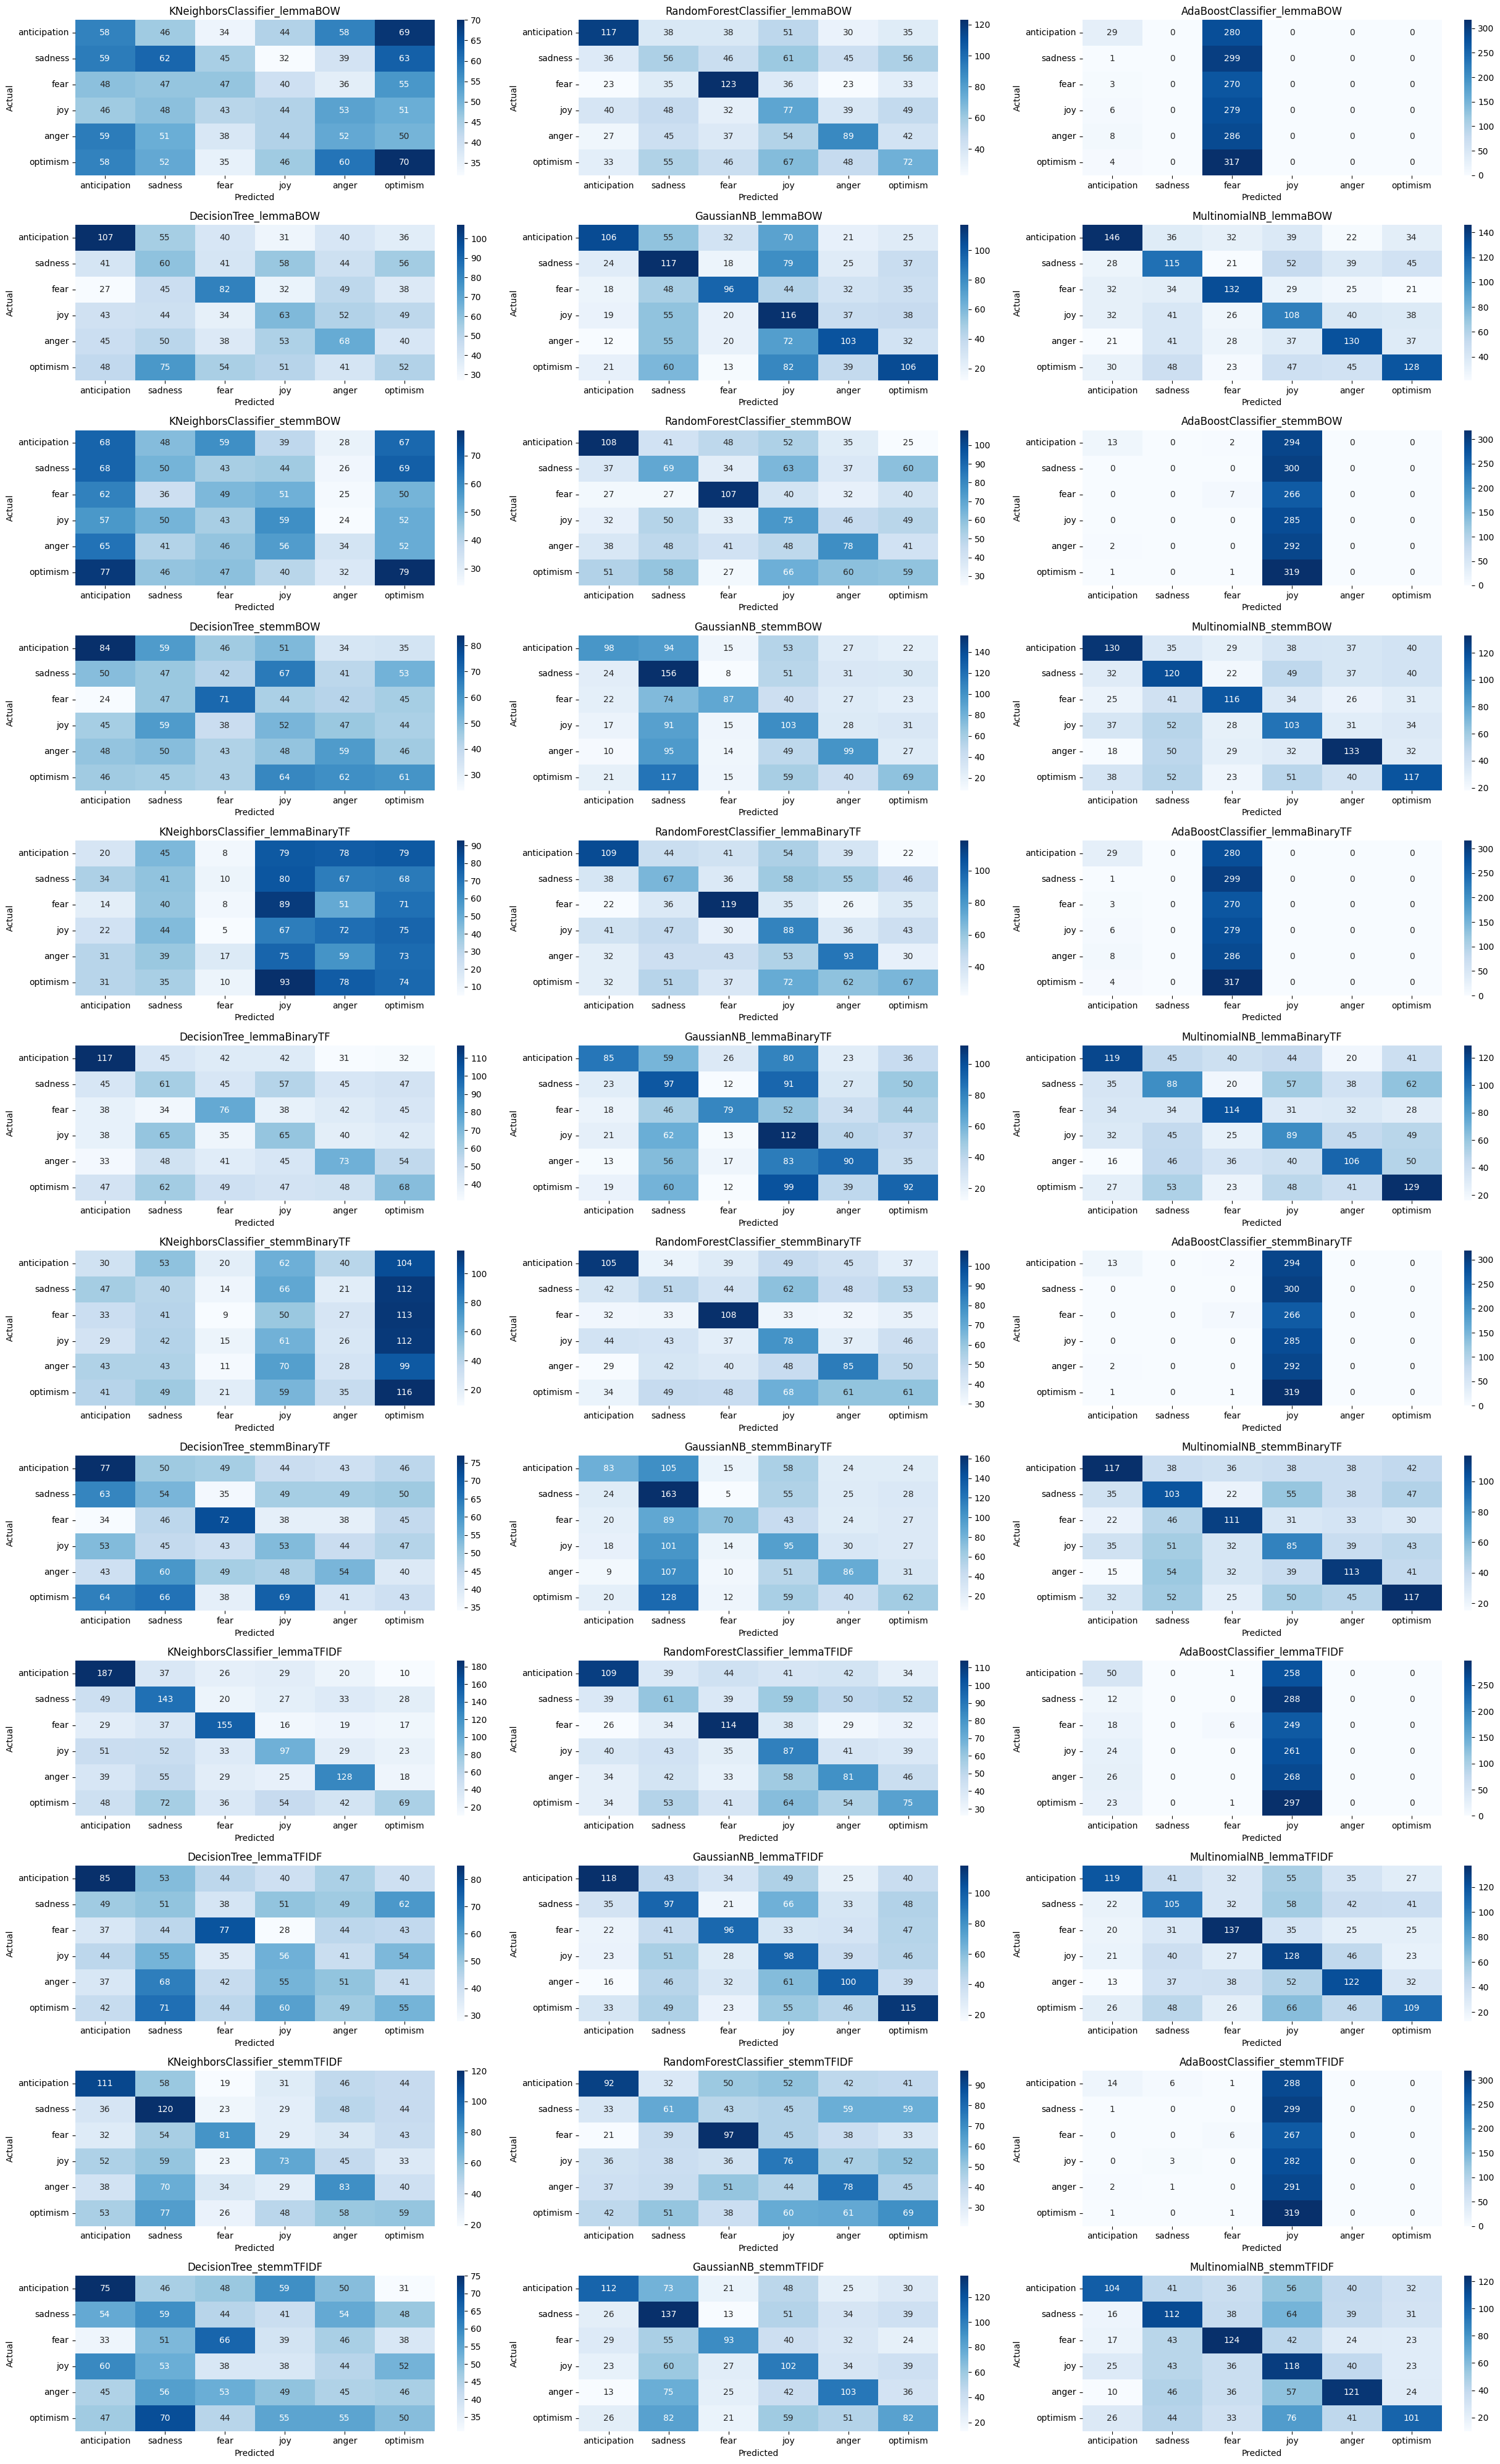

In [ ]:
import seaborn as sns
# Configura la figura y los ejes para mostrar 12 filas y 3 columnas de matrices de confusión.
fig, axes = plt.subplots(ncols=3, nrows=12, figsize=(25, 40))

# Obtiene las etiquetas únicas de la columna "emotion" en tu DataFrame.
labels_confmts = sampled_df["emotion"].unique().tolist()

comb_cont = 0  # Inicializa un contador para las combinaciones

# Itera a través de las filas (0 a 11) y columnas (0 a 2) de los subgráficos.
for i in range(0, 12):
    for j in range(3):
        ax = axes[i, j]  # Accede a cada subgráfico
        conf_mt = conf_mts[comb_cont]  # Obtiene la matriz de confusión correspondiente al contador de combinaciones

        # Crea un heatmap de la matriz de confusión, con anotaciones, formato de número entero y el esquema de colores "Blues".
        sns.heatmap(conf_mt, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=labels_confmts, yticklabels=labels_confmts)

        # Configura el título y las etiquetas de los ejes del subgráfico.
        ax.set(
            title=f"{combinaciones1[comb_cont]}",  # Título usando la combinación correspondiente
            ylabel="Actual",  # Etiqueta del eje Y
            xlabel="Predicted"  # Etiqueta del eje X
        )

        comb_cont += 1  # Incrementa el contador de combinaciones para la siguiente iteración

# Ajusta la disposición para que no se superpongan los elementos.
plt.tight_layout()
# Muestra la figura con las matrices de confusión.
plt.show()


### Guardando datos del modelo que mejor se comportó para tunearlo

In [ ]:
#vectorizadores

In [ ]:
# MODELO DE PEOR DESEMPEÑO

# Seleccionar el primer DataFrame en la lista vectorizadores
vectorizado = vectorizadores[1][1] # el de  menor performance

# Eliminar la columna 'emotion' de 'trial' para obtener X
X = vectorizado.drop(columns=["emotion"]).to_numpy()

# Asignar la columna 'emotion' a y
y = vectorizado ["emotion"].to_numpy()

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = KNeighborsClassifier()

clf.fit(X_train, y_train)


clf.score(X_test, y_test)

y_preds = clf.predict(X_test)
accuracy_score(y_test, y_preds)


0.15937149270482603

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

In [ ]:

# MODELO DE MEJOR DESEMPEÑO

# Seleccionar el primer DataFrame en la lista vectorizadores
vectorizado = vectorizadores[2][0] # el de  mejor performance

# Eliminar la columna 'emotion' de 'vectorizado' para obtener X
X = vectorizado.drop(columns=["emotion"]).to_numpy()

# Asignar la columna 'emotion' a y
y = vectorizado ["emotion"].to_numpy()

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = KNeighborsClassifier().fit(X_train, y_train) # Modelo de clasificación que vimos que tiene mejor desempeño.

clf.score(X_test, y_test)

y_preds = clf.predict(X_test)
accuracy_score(y_test, y_preds)

0.4371492704826038

In [ ]:
lemma_sampled_df

,training_tokens_lemma
0,apprehensive say least went see tangled disapp...
1,drug film combine comedy drama romance film ba...
2,case aware make officially influential storyte...
3,teen highly recommend movie much better freaky...
4,saw movie knowing tarkovski amusing thought ne...
...,...
8903,liked series lately ups down held interest spo...
8904,summarize clean entertainment good comedy impe...
8905,excited see film teaser seemed funny enough he...
8906,damnit ashamed hollywood approved stupid movie...


In [ ]:
lemma_tfidf_input

,100th,14th,15th,17th,18th,1990s,19th,20th,21st,30something,...,zurich,zuyeniko,zwart,zwick,zydeco,ànd,ænigma,élan,époque,époux
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8904,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

# MODELO DE MEJOR DESEMPEÑO - hyperparameter tuning

# Seleccionar el primer DataFrame en la lista vectorizadores
vectorizado = vectorizadores[2][0] # el de  mejor performance

# Eliminar la columna 'emotion' de 'vectorizado' para obtener X
X = vectorizado.drop(columns=["emotion"]).to_numpy()

# Asignar la columna 'emotion' a y
y = vectorizado ["emotion"].to_numpy()

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


train_score = {}
test_score = {}



n_neighbors = np.arange(2,  32, 1)

for neighbor in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train);_
    train_score[neighbor] = knn.score(X_train, y_train)
    test_score[neighbor] =  knn.score(X_test, y_test)



In [ ]:
for key, value in test_score.items():
    if value == max(test_score.values()):
        print(key);

5


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=44)
parameter = {"n_neighbors": np.arange(2, 32, 1)}
knn = KNeighborsClassifier();
knn_cv = GridSearchCV(knn, parameter, cv=kf, verbose=1)
knn_cv.fit(X_train, y_train)

print(knn_cv.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'n_neighbors': 5}


In [ ]:

# MODELO DE MEJOR DESEMPEÑO - hyperparameter tuning

# Seleccionar el primer DataFrame en la lista vectorizadores
vectorizado = vectorizadores[2][0] # el de  mejor performance

# Eliminar la columna 'emotion' de 'vectorizado' para obtener X
X = vectorizado.drop(columns=["emotion"]).to_numpy()

# Asignar la columna 'emotion' a y
y = vectorizado ["emotion"].to_numpy()

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn  =  KNeighborsClassifier(n_neighbors=7);

knn.fit(X_train, y_train);

y_preds = knn.predict(X_test);

acc_knn = accuracy_score(y_test, y_preds)
f1_knn = f1_score(y_test, y_preds, average="weighted")
recall_knn = recall_score(y_test, y_preds, average="weighted")

In [ ]:
print("Accuracy: {} \nF1 score: {} \nRecall: {}".format(acc_knn, f1_knn, recall_knn))

Accuracy: 0.4281705948372615 
F1 score: 0.4164058241391098 
Recall: 0.4281705948372615


In [ ]:
cof_mt = confusion_matrix(y_test, y_preds, labels = list(vectorizado["emotion"].unique()))

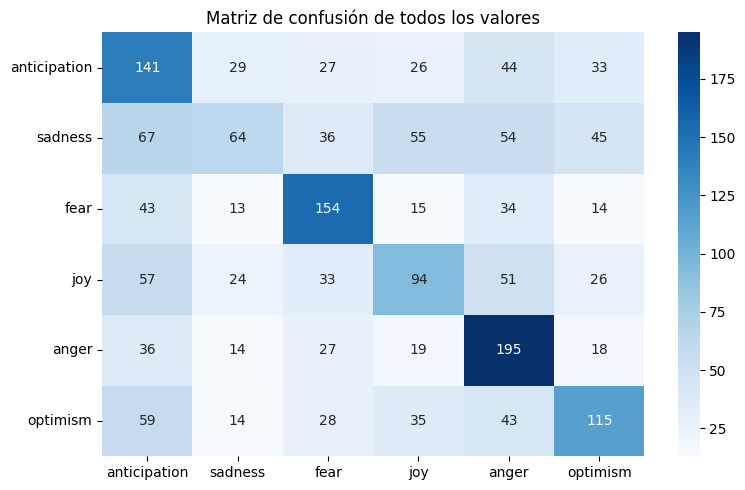

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))

sns.heatmap(cof_mt, fmt='d', annot=True, cmap="Blues", xticklabels=list(vectorizado["emotion"].unique()), yticklabels=list(vectorizado["emotion"].unique()))

ax.set(
    title="Matriz de confusión de todos los valores"
)

plt.tight_layout()
plt.show()

In [ ]:
f"{round(np.trace(cof_mt) / np.sum(cof_mt) * 100, 2)}%"

'42.82%'

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Suponiendo que y_train y y_test son etiquetas en formato de texto
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  # Convierte las etiquetas de entrenamiento a números
y_test_encoded = encoder.transform(y_test)  # Convierte las etiquetas de prueba a números

array(['anticipation', 'anger', 'optimism', ..., 'optimism', 'anger',
       'anticipation'], dtype=object)

In [ ]:
"""import pickle

# Guardar el modelo en un archivo .pkl
with open("modelo/model.pkl", "wb") as file:
    pickle.dump(knn, file)

# Guardar el vectorizador en un archivo .pkl
with open("modelo/x_test.pkl", "wb") as file:
    pickle.dump(X_test, file)"""


'import pickle\n\n# Guardar el modelo en un archivo .pkl\nwith open("modelo/model.pkl", "wb") as file:\n    pickle.dump(knn, file)\n\n# Guardar el vectorizador en un archivo .pkl\nwith open("modelo/x_test.pkl", "wb") as file:\n    pickle.dump(X_test, file)'

###  Fuentes:
Dealing with contractions in NLP: https://medium.com/@lukei_3514/dealing-with-contractions-in-nlp-d6174300876b

El dataset fue obtenido de: https://www.kaggle.com/datasets/fahadrehman07/movie-reviews-and-emotion-dataset